# CS4168 Data Mining Group Project — Spotify Tracks 2026

**Use this as a project notebook scaffold.**  
It contains a complete, runnable workflow for EDA, clustering, classification, and regression based on the assignment specification.  
Before submitting, add your group’s own commentary, interpretation, screenshots/video narration, and any extra experiments you run.

## 1. Setup and load data

The assignment requires using `tracks2026.csv` only. The original Hugging Face dataset should not be used.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

RANDOM_STATE = 42

df = pd.read_csv("tracks2026 (1).csv")
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


## 2. Initial data audit

Key things to check:
- shape and column types,
- missing values,
- duplicate rows and duplicate track IDs,
- possible invalid/outlier values.

In [2]:
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate track_id values:", df["track_id"].duplicated().sum())
print("\nGenres:")
display(df["track_genre"].value_counts())

Shape: (2000, 17)


,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          2000 non-null   object 
 1   popularity        1960 non-null   float64
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   danceability      1960 non-null   float64
 5   energy            1960 non-null   float64
 6   key               2000 non-null   int64  
 7   loudness          1961 non-null   float64
 8   mode              2000 non-null   int64  
 9   speechiness       2000 non-null   float64
 10  acousticness      2000 non-null   float64
 11  instrumentalness  2000 non-null   float64
 12  liveness          2000 non-null   float64
 13  valence           2000 non-null   float64
 14  tempo             1960 non-null   float64
 15  time_signature    2000 non-null   int64  
 16  track_genre       2000 non-null   object 


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,2000,1968,3uRrymHwcED49Q4fAnJJgD,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,1960.0,NaN,NaN,NaN,39.805102,29.245904,0.0,1.75,45.0,65.0,100.0
duration_ms,2000.0,NaN,NaN,NaN,217806.433,56804.759189,60000.0,181210.0,211346.0,246069.75,561133.0
explicit,2000,2,False,1777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,1960.0,NaN,NaN,NaN,0.635897,0.138298,0.185,0.548,0.646,0.738,0.953
energy,1960.0,NaN,NaN,NaN,0.632489,0.189087,0.0909,0.50775,0.644,0.78,0.996
key,2000.0,NaN,NaN,NaN,5.2955,3.567148,0.0,2.0,5.0,8.0,11.0
loudness,1961.0,NaN,NaN,NaN,400.575884,18065.717039,-21.089,-8.988,-6.924,-5.39,800000.0
mode,2000.0,NaN,NaN,NaN,0.6375,0.480842,0.0,0.0,1.0,1.0,1.0
speechiness,2000.0,NaN,NaN,NaN,0.078466,0.076223,0.0221,0.034475,0.0475,0.08495,0.515



Missing values:


tempo               40
danceability        40
energy              40
popularity          40
loudness            39
track_id             0
instrumentalness     0
time_signature       0
valence              0
liveness             0
mode                 0
acousticness         0
speechiness          0
key                  0
explicit             0
duration_ms          0
track_genre          0
dtype: int64


Duplicate rows: 6
Duplicate track_id values: 32

Genres:


track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64

### Data cleaning decision

The dataset contains missing values in `popularity`, `danceability`, `energy`, `loudness`, and `tempo`.
For modelling, missing target values are removed. Missing feature values are handled inside scikit-learn pipelines using median imputation.

One `loudness` value is extremely large and unrealistic for Spotify loudness, so the code below treats values greater than 5 dB as missing. This is a defensible preprocessing choice because normal track loudness values are usually negative or close to 0.

In [3]:
df_clean = df.copy()
df_clean.loc[df_clean["loudness"] > 5, "loudness"] = np.nan
df_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,2000,1968,3uRrymHwcED49Q4fAnJJgD,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,1960.0,NaN,NaN,NaN,39.805102,29.245904,0.0,1.75,45.0,65.0,100.0
duration_ms,2000.0,NaN,NaN,NaN,217806.433,56804.759189,60000.0,181210.0,211346.0,246069.75,561133.0
explicit,2000,2,False,1777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,1960.0,NaN,NaN,NaN,0.635897,0.138298,0.185,0.548,0.646,0.738,0.953
energy,1960.0,NaN,NaN,NaN,0.632489,0.189087,0.0909,0.50775,0.644,0.78,0.996
key,2000.0,NaN,NaN,NaN,5.2955,3.567148,0.0,2.0,5.0,8.0,11.0
loudness,1960.0,NaN,NaN,NaN,-7.383006,2.876789,-21.089,-8.98875,-6.924,-5.39225,-0.079
mode,2000.0,NaN,NaN,NaN,0.6375,0.480842,0.0,0.0,1.0,1.0,1.0
speechiness,2000.0,NaN,NaN,NaN,0.078466,0.076223,0.0221,0.034475,0.0475,0.08495,0.515


## 3. Exploratory Data Analysis

Use these plots to describe the dataset and connect observations to modelling decisions.

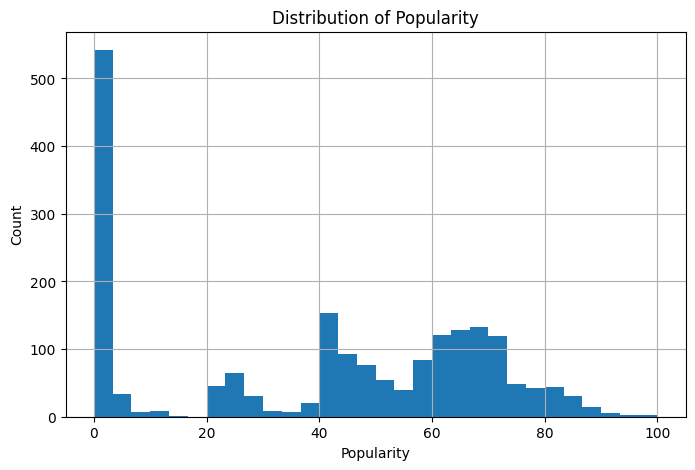

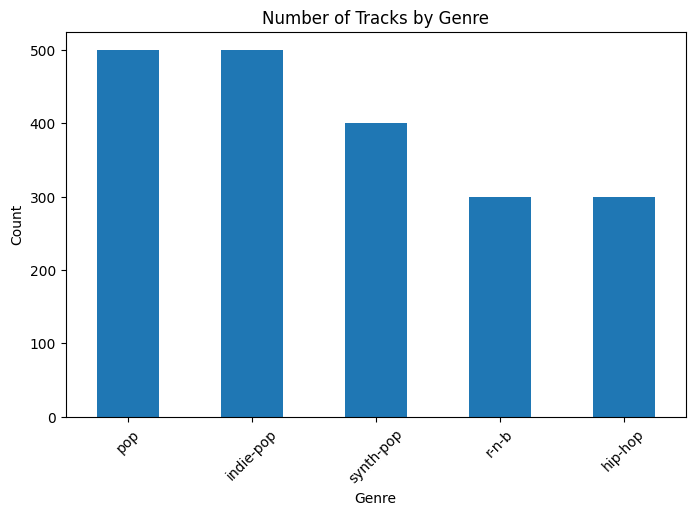

<Figure size 800x500 with 0 Axes>

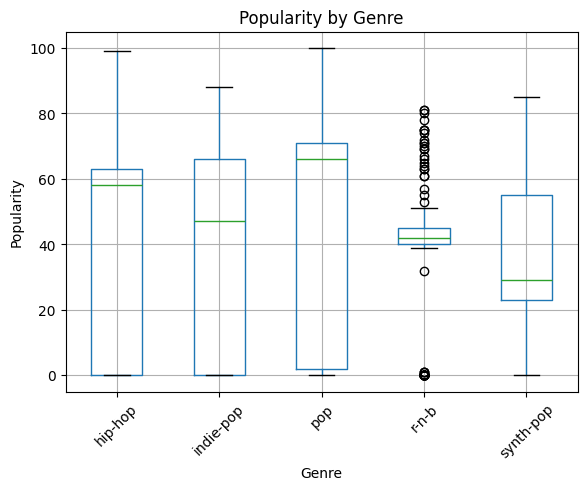

In [4]:
# Target distribution
plt.figure(figsize=(8, 5))
df_clean["popularity"].hist(bins=30)
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

# Genre distribution
plt.figure(figsize=(8, 5))
df_clean["track_genre"].value_counts().plot(kind="bar")
plt.title("Number of Tracks by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Popularity by genre
plt.figure(figsize=(8, 5))
df_clean.boxplot(column="popularity", by="track_genre", rot=45)
plt.title("Popularity by Genre")
plt.suptitle("")
plt.xlabel("Genre")
plt.ylabel("Popularity")
plt.show()

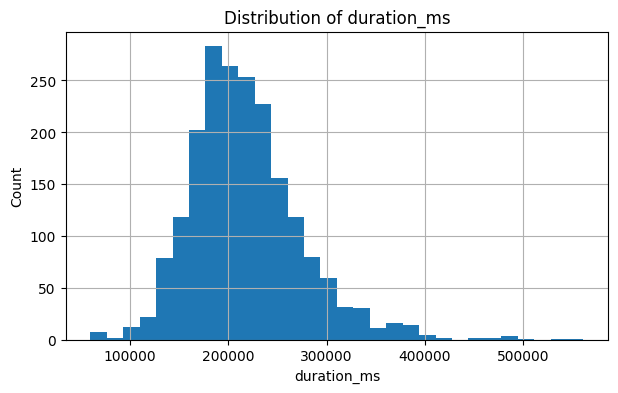

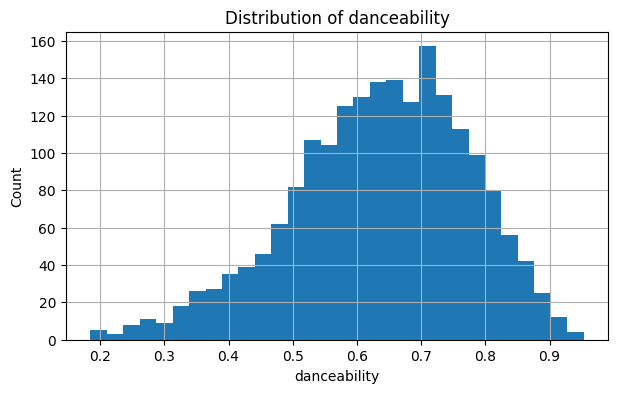

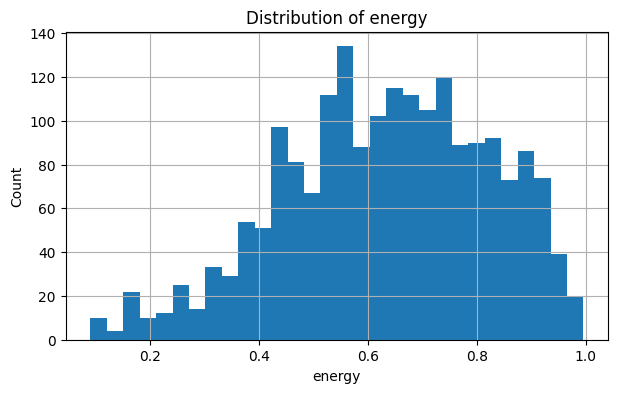

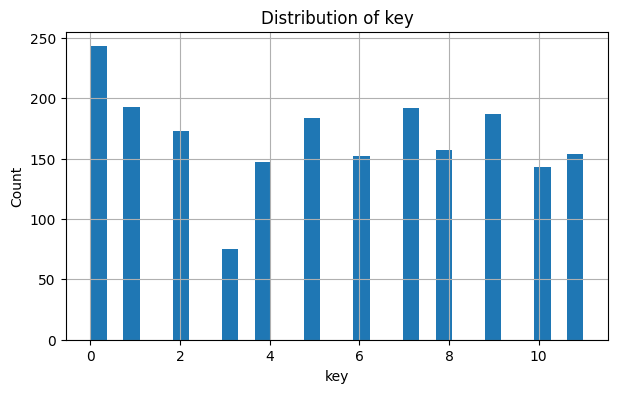

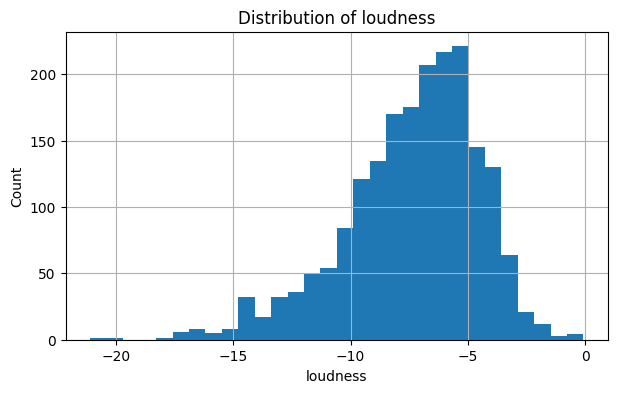

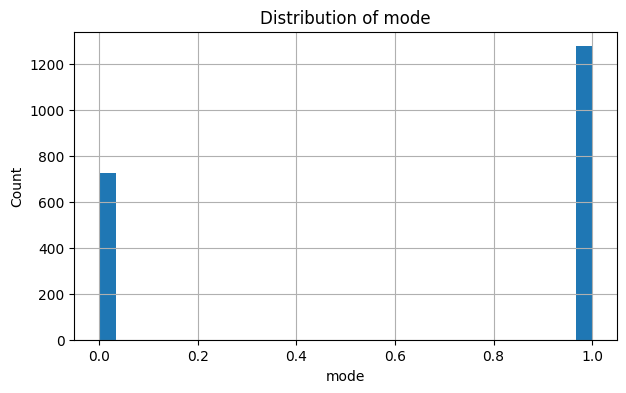

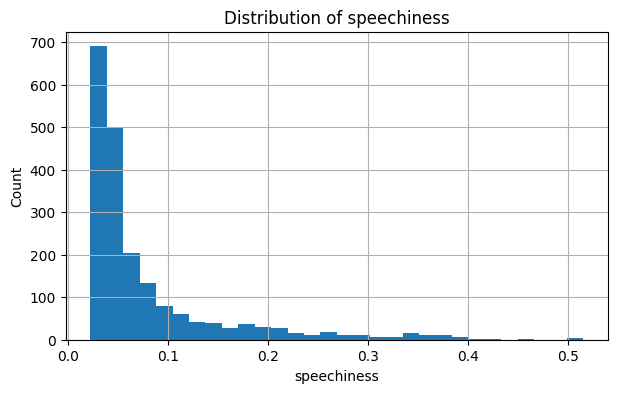

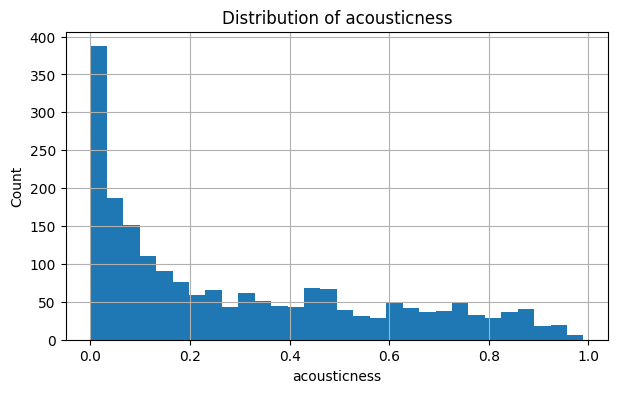

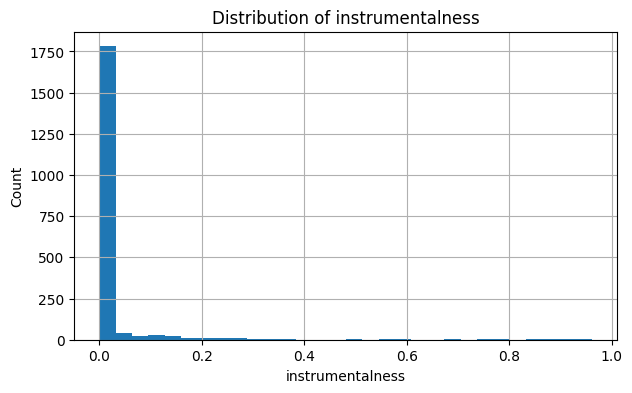

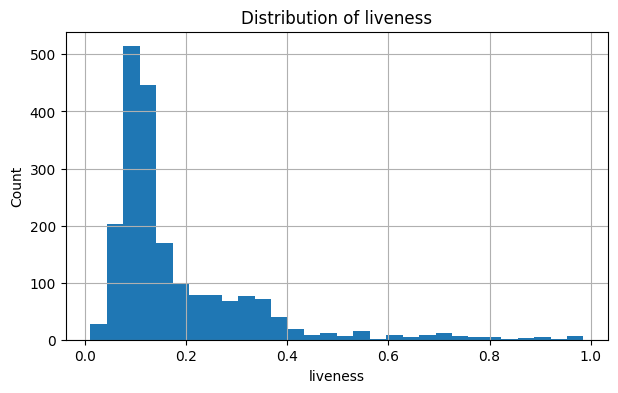

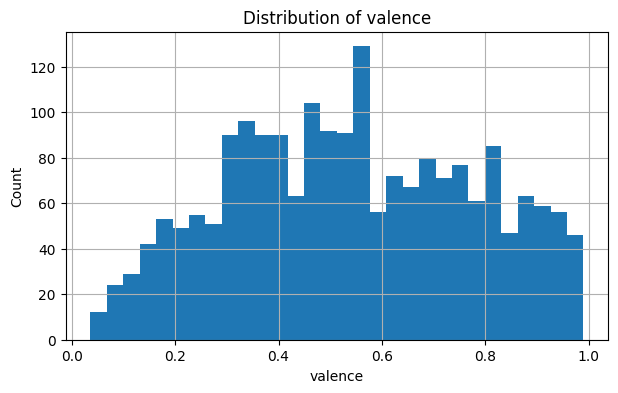

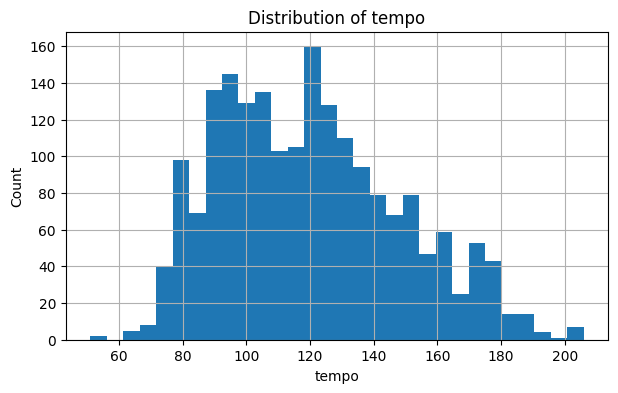

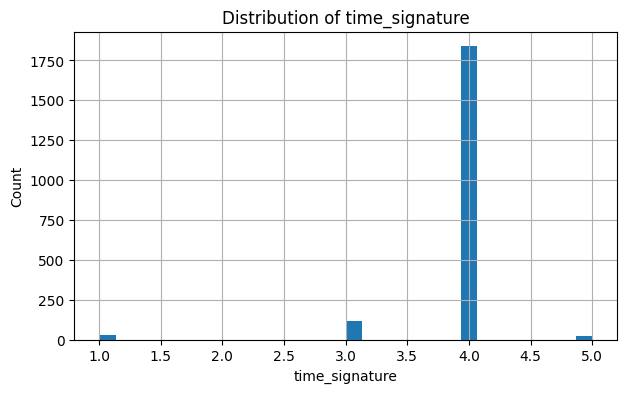

In [5]:
# Numeric feature distributions
numeric_cols = df_clean.select_dtypes(include=np.number).columns.drop("popularity")
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    df_clean[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

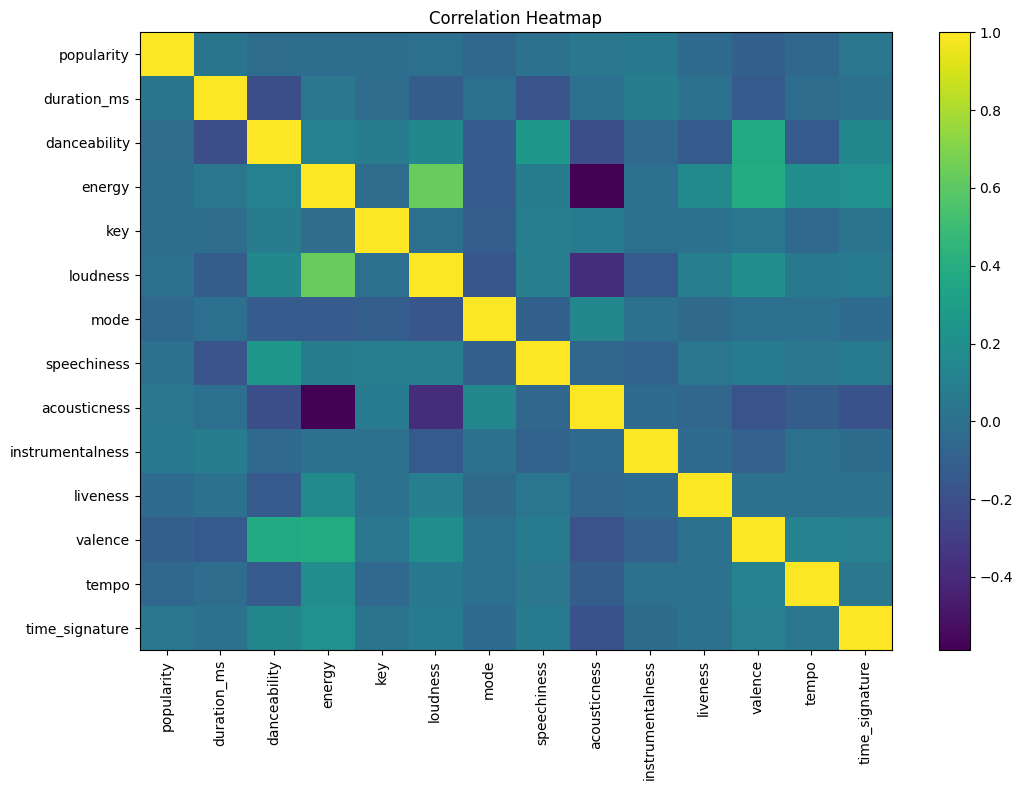

popularity          1.000000
instrumentalness    0.052461
acousticness        0.049778
time_signature      0.032678
duration_ms         0.026282
speechiness         0.004288
loudness           -0.010803
key                -0.013315
energy             -0.017372
danceability       -0.023186
liveness           -0.033469
mode               -0.050896
tempo              -0.056942
valence            -0.100355
Name: popularity, dtype: float64

In [6]:
# Correlation heatmap for numeric variables
corr = df_clean.select_dtypes(include=np.number).corr()

plt.figure(figsize=(11, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

display(corr["popularity"].sort_values(ascending=False))

### EDA interpretation prompts

Add your own interpretation here. Useful points to discuss:
- the dataset is balanced across some genres but not all,
- missing values are present and require imputation,
- popularity has many low and mid-range values,
- exact popularity may be difficult to predict because audio features alone do not capture marketing, artist fame, playlist placement, or release date,
- outliers such as the unrealistic loudness value can distort distance-based models, so scaling and outlier handling matter.

## 4. Clustering: K-means and DBSCAN

Assignment requirement: **drop `track_genre` for clustering**.  
We also drop `track_id` because it is an identifier, not a meaningful numeric/categorical feature.

`popularity` is retained here because the specification only says to drop `track_genre`. If your lecturer expects popularity to be excluded from unsupervised clustering, run the same code again with `popularity` removed and compare.

In [7]:
cluster_df = df_clean.drop(columns=["track_genre", "track_id"])
cluster_numeric = cluster_df.select_dtypes(include=np.number).columns.tolist()
cluster_categorical = cluster_df.select_dtypes(exclude=np.number).columns.tolist()

cluster_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), cluster_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cluster_categorical)
    ]
)

X_cluster = cluster_preprocess.fit_transform(cluster_df)
genre_codes = pd.factorize(df_clean["track_genre"])[0]  # only for external comparison after clustering

print("Cluster matrix shape:", X_cluster.shape)

Cluster matrix shape: (2000, 16)


,k,inertia,silhouette,ARI_vs_genre
0,2,24939.198699,0.138102,0.011294
1,3,23359.566895,0.142689,0.010421
2,4,22172.674821,0.101475,0.043541
3,5,20750.732098,0.099662,0.033981
4,6,19571.200592,0.113627,0.034093
5,7,18537.659506,0.112725,0.038017
6,8,17639.209478,0.119563,0.040316
7,9,17128.008748,0.111255,0.037962
8,10,16594.783100,0.108764,0.033586


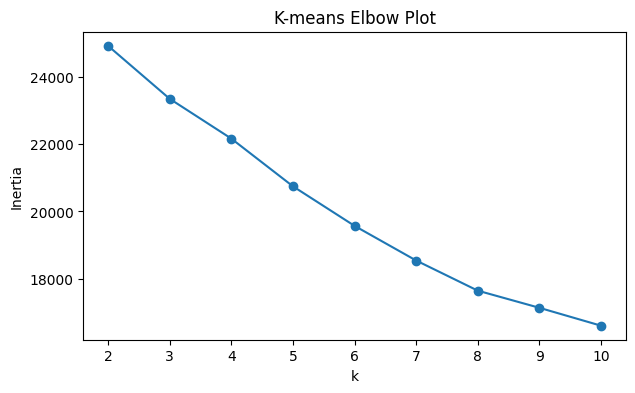

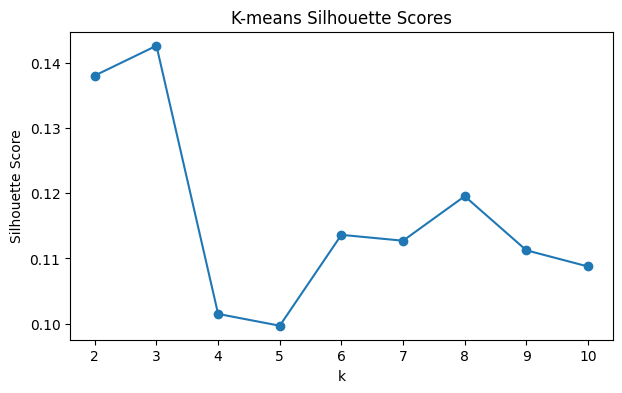

In [8]:
# K-means: compare several k values using inertia and silhouette
k_values = range(2, 11)
kmeans_results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    kmeans_results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_cluster, labels),
        "ARI_vs_genre": adjusted_rand_score(genre_codes, labels)
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results)

plt.figure(figsize=(7, 4))
plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
plt.title("K-means Elbow Plot")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
plt.title("K-means Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

In [9]:
# Compare at least two k values, e.g., k=3 and k=5
for k in [3, 5]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    print(f"\nK-means k={k}")
    print("Silhouette:", round(silhouette_score(X_cluster, labels), 3))
    print("ARI vs genre:", round(adjusted_rand_score(genre_codes, labels), 3))
    display(pd.crosstab(labels, df_clean["track_genre"], normalize="index").round(2))


K-means k=3
Silhouette: 0.143
ARI vs genre: 0.01


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,0.02,0.31,0.09,0.02,0.56
1,0.06,0.36,0.28,0.16,0.14
2,0.20,0.19,0.24,0.15,0.22



K-means k=5
Silhouette: 0.1
ARI vs genre: 0.034


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,0.02,0.32,0.09,0.02,0.55
1,0.40,0.15,0.25,0.16,0.04
2,0.05,0.37,0.29,0.18,0.11
3,0.19,0.19,0.29,0.11,0.22
4,0.10,0.25,0.18,0.18,0.30


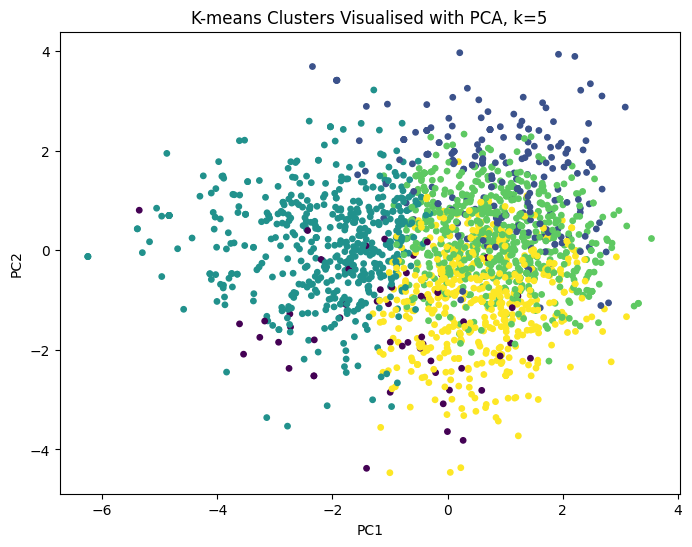

,popularity,danceability,energy,acousticness,instrumentalness,track_genre
cluster,,,,,,
0,51.135,0.596,0.637,0.226,0.681,synth-pop
1,36.317,0.724,0.640,0.289,0.012,hip-hop
2,43.922,0.554,0.422,0.609,0.013,indie-pop
3,40.224,0.712,0.700,0.187,0.011,pop
4,35.608,0.587,0.750,0.146,0.014,synth-pop


In [10]:
# PCA visualisation of K-means clusters
chosen_k = 5
km_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = km_final.fit_predict(X_cluster)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, s=15)
plt.title(f"K-means Clusters Visualised with PCA, k={chosen_k}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

cluster_summary = df_clean.assign(cluster=kmeans_labels).groupby("cluster").agg({
    "popularity": "mean",
    "danceability": "mean",
    "energy": "mean",
    "acousticness": "mean",
    "instrumentalness": "mean",
    "track_genre": lambda x: x.value_counts().index[0]
}).round(3)
display(cluster_summary)

In [11]:
# DBSCAN parameter search
dbscan_results = []
for eps in [1.5, 2, 2.5, 3, 3.5, 4]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_cluster)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)
    sil = np.nan
    if n_clusters > 1:
        sil = silhouette_score(X_cluster, labels)
    dbscan_results.append({
        "eps": eps,
        "min_samples": 10,
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": sil
    })

dbscan_results = pd.DataFrame(dbscan_results)
display(dbscan_results)

,eps,min_samples,n_clusters,noise_ratio,silhouette
0,1.5,10,9,0.9485,-0.255515
1,2.0,10,3,0.4740,-0.010207
2,2.5,10,3,0.2040,0.000833
3,3.0,10,2,0.0735,0.294099
4,3.5,10,3,0.0315,0.340134
5,4.0,10,2,0.0080,0.407898


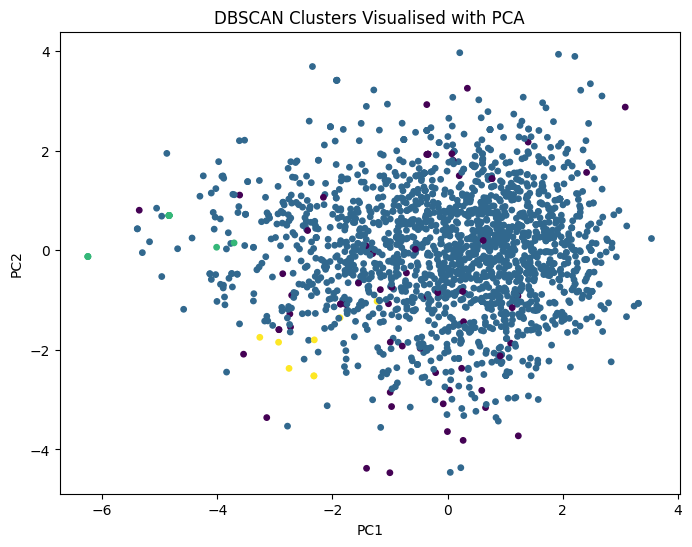

Clusters excluding noise: 3
Noise ratio: 0.032


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
-1,0.21,0.21,0.10,0.14,0.35
0,0.15,0.25,0.25,0.15,0.20
1,0.00,0.15,0.85,0.00,0.00
2,0.00,0.62,0.25,0.00,0.12


In [12]:
# Visualise a chosen DBSCAN solution
db_final = DBSCAN(eps=3.5, min_samples=10)
db_labels = db_final.fit_predict(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, s=15)
plt.title("DBSCAN Clusters Visualised with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Clusters excluding noise:", len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise ratio:", round(np.mean(db_labels == -1), 3))
display(pd.crosstab(db_labels, df_clean["track_genre"], normalize="index").round(2))

### Clustering interpretation prompts

Add your own conclusion here. Likely finding:
- K-means gives usable partitions but the ARI against genre may be low, meaning clusters do not strongly reproduce genre labels.
- DBSCAN is sensitive to `eps`; small `eps` may label many points as noise, while large `eps` can merge most points into only a few clusters.
- This suggests genre is not fully separable using these audio features alone, or the genre labels overlap musically.

## 5. Classification: predicting high/low popularity

Create `popularity_binary` using the median of `popularity`.

Assignment requirement:
- `popularity_binary = 0` if popularity ≤ median
- `popularity_binary = 1` if popularity > median
- remove original `popularity` column
- compare multiple models and justify the final choice

In [13]:
class_df = df_clean.dropna(subset=["popularity"]).copy()
median_popularity = class_df["popularity"].median()
class_df["popularity_binary"] = (class_df["popularity"] > median_popularity).astype(int)

print("Median popularity:", median_popularity)
display(class_df["popularity_binary"].value_counts(normalize=True).rename("proportion"))

X_class = class_df.drop(columns=["popularity", "popularity_binary", "track_id"])
y_class = class_df["popularity_binary"]

class_numeric = X_class.select_dtypes(include=np.number).columns.tolist()
class_categorical = X_class.select_dtypes(exclude=np.number).columns.tolist()

class_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), class_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), class_categorical)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

Median popularity: 45.0


popularity_binary
0    0.507143
1    0.492857
Name: proportion, dtype: float64

In [14]:
class_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=1
    )
}

class_results = []

for name, model in class_models.items():
    pipe = Pipeline([
        ("preprocess", class_preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    class_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)
    })

class_results = pd.DataFrame(class_results).sort_values("f1", ascending=False)
display(class_results.round(3))

,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.727,0.724,0.720,0.722,0.810
0,Logistic Regression,0.625,0.613,0.648,0.630,0.666
1,Decision Tree,0.630,0.638,0.575,0.605,0.657


In [15]:
# Optional hyperparameter tuning for the best family
rf_pipe = Pipeline([
    ("preprocess", class_preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [1, 3, 5]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=1
)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))

best_class_model = grid.best_estimator_
test_preds = best_class_model.predict(X_test)
test_probs = best_class_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, test_preds))
print("Test ROC-AUC:", round(roc_auc_score(y_test, test_probs), 3))
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_test, test_preds),
                     index=["Actual low", "Actual high"],
                     columns=["Pred low", "Pred high"]))

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV F1: 0.701
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       199
           1       0.74      0.72      0.73       193

    accuracy                           0.73       392
   macro avg       0.73      0.73      0.73       392
weighted avg       0.73      0.73      0.73       392

Test ROC-AUC: 0.802
Confusion matrix:


,Pred low,Pred high
Actual low,149,50
Actual high,54,139


,feature,importance
7,num__acousticness,0.095904
11,num__tempo,0.093031
0,num__duration_ms,0.086592
1,num__danceability,0.085925
6,num__speechiness,0.084019
10,num__valence,0.082781
4,num__loudness,0.082711
2,num__energy,0.081111
9,num__liveness,0.073528
8,num__instrumentalness,0.058102


<Figure size 800x500 with 0 Axes>

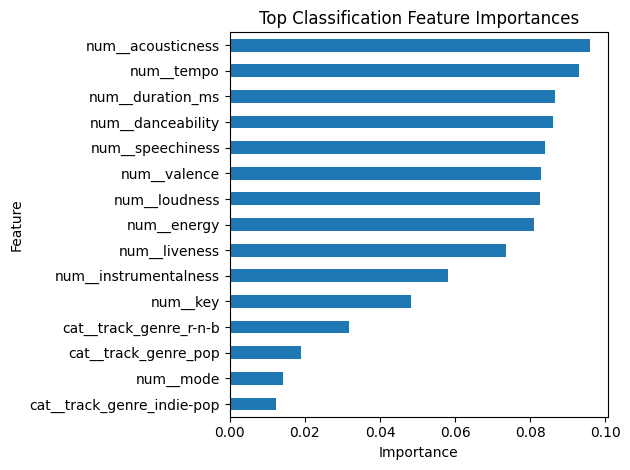

In [16]:
# Feature importance for random forest
feature_names = best_class_model.named_steps["preprocess"].get_feature_names_out()
importances = best_class_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(8, 5))
importance_df.head(15).sort_values("importance").plot(
    kind="barh", x="feature", y="importance", legend=False
)
plt.title("Top Classification Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Classification interpretation prompts

Add a short model choice justification:
- F1 is a good selection metric because the target classes are near-balanced but both false positives and false negatives matter.
- Accuracy is easy to interpret, but F1 and ROC-AUC give a fuller picture.
- Random Forest is often expected to perform best because it captures non-linear relationships and interactions between audio features and genre.

## 6. Regression: predicting exact popularity score

For regression, use the original popularity score as the target. Do not binarise it.

In [17]:
reg_df = df_clean.dropna(subset=["popularity"]).copy()

X_reg = reg_df.drop(columns=["popularity", "track_id"])
y_reg = reg_df["popularity"]

reg_numeric = X_reg.select_dtypes(include=np.number).columns.tolist()
reg_categorical = X_reg.select_dtypes(exclude=np.number).columns.tolist()

reg_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), reg_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), reg_categorical)
    ]
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

In [18]:
reg_models = {
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=1
    )
}

reg_results = []

for name, model in reg_models.items():
    pipe = Pipeline([
        ("preprocess", reg_preprocess),
        ("model", model)
    ])
    pipe.fit(Xr_train, yr_train)
    preds = pipe.predict(Xr_test)
    reg_results.append({
        "model": name,
        "MAE": mean_absolute_error(yr_test, preds),
        "RMSE": np.sqrt(mean_squared_error(yr_test, preds)),
        "R2": r2_score(yr_test, preds)
    })

reg_results = pd.DataFrame(reg_results).sort_values("MAE")
display(reg_results.round(3))

,model,MAE,RMSE,R2
2,Random Forest,19.117,24.415,0.293
1,Decision Tree,23.157,28.841,0.014
0,Ridge Regression,25.208,28.714,0.022


Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV MAE: 20.003
Test MAE: 18.722
Test RMSE: 24.497
Test R2: 0.288


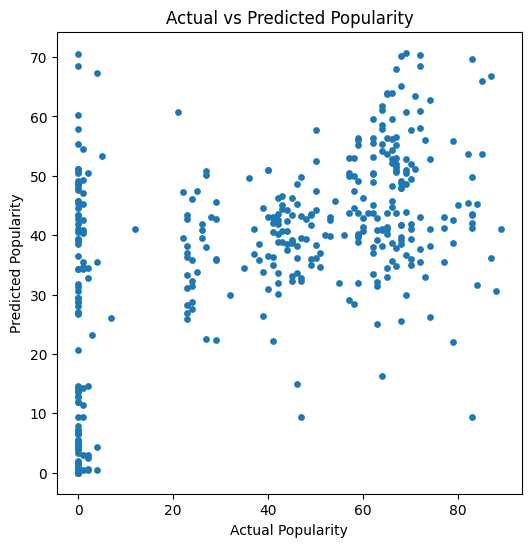

In [19]:
# Optional tuning for Random Forest regression
rf_reg_pipe = Pipeline([
    ("preprocess", reg_preprocess),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [1, 3, 5]
}

reg_grid = GridSearchCV(
    rf_reg_pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=1
)

reg_grid.fit(Xr_train, yr_train)
print("Best parameters:", reg_grid.best_params_)
print("Best CV MAE:", round(-reg_grid.best_score_, 3))

best_reg_model = reg_grid.best_estimator_
reg_preds = best_reg_model.predict(Xr_test)

print("Test MAE:", round(mean_absolute_error(yr_test, reg_preds), 3))
print("Test RMSE:", round(np.sqrt(mean_squared_error(yr_test, reg_preds)), 3))
print("Test R2:", round(r2_score(yr_test, reg_preds), 3))

plt.figure(figsize=(6, 6))
plt.scatter(yr_test, reg_preds, s=15)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity")
plt.show()

,feature,importance
7,num__acousticness,0.106822
11,num__tempo,0.093336
10,num__valence,0.091877
6,num__speechiness,0.088255
0,num__duration_ms,0.087422
1,num__danceability,0.086337
2,num__energy,0.081950
4,num__loudness,0.080237
9,num__liveness,0.069448
8,num__instrumentalness,0.067532


<Figure size 800x500 with 0 Axes>

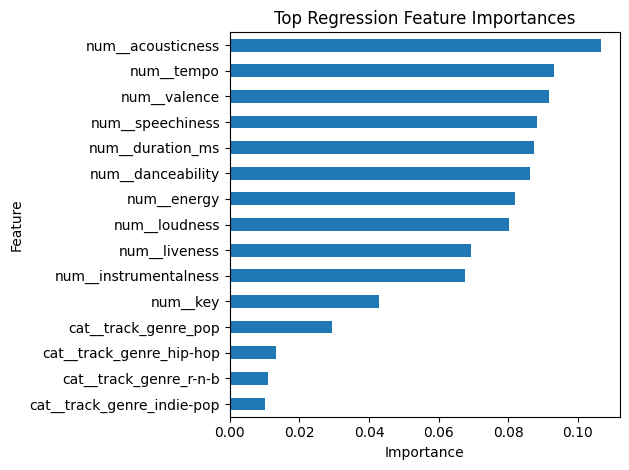

In [20]:
# Regression feature importance
feature_names = best_reg_model.named_steps["preprocess"].get_feature_names_out()
importances = best_reg_model.named_steps["model"].feature_importances_

reg_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(reg_importance_df.head(15))

plt.figure(figsize=(8, 5))
reg_importance_df.head(15).sort_values("importance").plot(
    kind="barh", x="feature", y="importance", legend=False
)
plt.title("Top Regression Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Regression interpretation prompts

Discuss whether exact popularity is harder than high/low classification.

A strong critical point: exact popularity is probably harder because popularity depends on many external factors not in this dataset, such as artist reputation, playlisting, release date, marketing, social media trends, and regional exposure. A binary threshold reduces the problem to separating more popular from less popular tracks, which loses detail but is easier to model.

## 7. Final project conclusion draft

Replace the bracketed text with your own interpretation.

**EDA:** The dataset contains 2,000 tracks across five genres. Missing values and an unrealistic loudness outlier required preprocessing. Popularity varies widely and does not appear to be explained by one simple audio feature.

**Clustering:** K-means and DBSCAN were both tested. K-means produced more stable cluster assignments, while DBSCAN was sensitive to the `eps` parameter. The clusters showed only limited alignment with known genre labels, suggesting that genres overlap in the numerical audio-feature space.

**Classification:** Popularity was converted into a binary target using the median. Multiple classifiers were compared using accuracy, precision, recall, F1, and ROC-AUC. The final model should be chosen based on the metric table and justified in terms of performance and interpretability.

**Regression:** Exact popularity prediction was more difficult than binary classification. Random Forest regression is likely to outperform a simple linear baseline, but the R² may remain limited because important popularity drivers are not included in the dataset.

## 8. Video demo outline

Use this for the 6-minute demo:
1. Dataset and objective: 30 seconds.
2. EDA highlights: missing values, genre balance, popularity distribution, loudness outlier: 90 seconds.
3. Clustering: K-means k choice, DBSCAN comparison, PCA plot, genre alignment: 90 seconds.
4. Classification: binary target, model comparison, final model, one useful feature-importance finding: 90 seconds.
5. Regression: model comparison, actual vs predicted plot, why exact prediction is harder: 60 seconds.
6. One decision that improved performance and one that reduced performance: 30 seconds.

Example improvement: treating the loudness outlier as missing and imputing within the pipeline.  
Example reduction: using DBSCAN with too-small `eps`, which labelled too many tracks as noise.